<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%202/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# Step 1.1: The "Latency" Trap

# Manual DGP Simulation
import numpy as np

normal_traffic = np.random.randint(20, 50, 980)
spike_traffic  = np.random.randint(1000, 5000, 20)
latency_logs   = np.concatenate([normal_traffic, spike_traffic])

# Quick check to verify it worked
print(f"Total requests: {len(latency_logs)}")
print(f"Mean latency:   {np.mean(latency_logs):.2f} ms")
print(f"Median latency: {np.median(latency_logs):.2f} ms")

Total requests: 1000
Mean latency:   90.80 ms
Median latency: 35.00 ms


In [35]:
# Step 1.2: Manual MAD vs. SD

import numpy as np
import matplotlib.pyplot as plt

# Recreate latency data
np.random.seed(42)
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic  = np.random.randint(1000, 5000, 20)
latency_logs   = np.concatenate([normal_traffic, spike_traffic])

# calculate_mad function
def calculate_mad(data):
    # 1. Calculate the Median of the data
    median = np.median(data)

    # 2. Calculate Absolute Deviations (|x - median|)
    absolute_deviations = np.abs(data - median)

    # 3. Return the Median of those deviations
    return np.median(absolute_deviations)

# Compare SD vs MAD
sd  = np.std(latency_logs)
mad = calculate_mad(latency_logs)

print(f"Standard Deviation (SD): {sd:.2f} ms")
print(f"Median Absolute Deviation (MAD): {mad:.2f} ms")

Standard Deviation (SD): 458.89 ms
Median Absolute Deviation (MAD): 8.00 ms


In [36]:
# Phase 2: The Probability Audit (Topic 5)
# Step 2.1: The False Positive Paradox

# Bayes' Theorem Formula:
# P(Cheater | Flagged) = (prior * sensitivity) /
#                        (prior * sensitivity + (1 - prior) * (1 - specificity))

def bayesian_audit(prior, sensitivity, specificity):
    # Numerator: P(Flagged | Cheater) * P(Cheater)
    true_positive  = prior * sensitivity

    # Denominator: add the false positive rate
    false_positive = (1 - prior) * (1 - specificity)

    # Posterior Probability
    posterior = true_positive / (true_positive + false_positive)

    return posterior

# Test the 3 Scenarios
sensitivity = 0.98
specificity = 0.98

print(bayesian_audit(0.50,  sensitivity, specificity))  # Scenario A: Bootcamp
print(bayesian_audit(0.05,  sensitivity, specificity))  # Scenario B: Econ Class
print(bayesian_audit(0.001, sensitivity, specificity))  # Scenario C: Honors Seminar

0.98
0.7205882352941175
0.04675572519083965


In [37]:
# Phase 3: The Bias Audit (Topic 6)
# Step 3.1: Detecting Sample Ratio Mismatch (SRM)

import numpy as np

# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
observed = np.array([50250, 49750])   # Control, Treatment
expected = np.array([50000, 50000])   # Perfect 50/50 split

# Write the calculation loop
chi_square = 0
for i in range(len(observed)):
    chi_square += (observed[i] - expected[i])**2 / expected[i]

print(f"Chi-Square Statistic: {chi_square:.4f}")

# Decision Rule: if > 3.84, p < 0.05 → experiment is INVALID
if chi_square > 3.84:
    print("INVALID: Sample Ratio Mismatch (SRM) Detected. Check Load Balancer.")
else:
    print("VALID: Variance is within natural limits.")

Chi-Square Statistic: 2.5000
VALID: Variance is within natural limits.


Total tokens:         10000
Survivors (Top 1%):   100
Mean Market Cap (All):       $6,960.54
Mean Market Cap (Survivors): $358,555.75
Survivorship Bias Multiplier: 51.5x


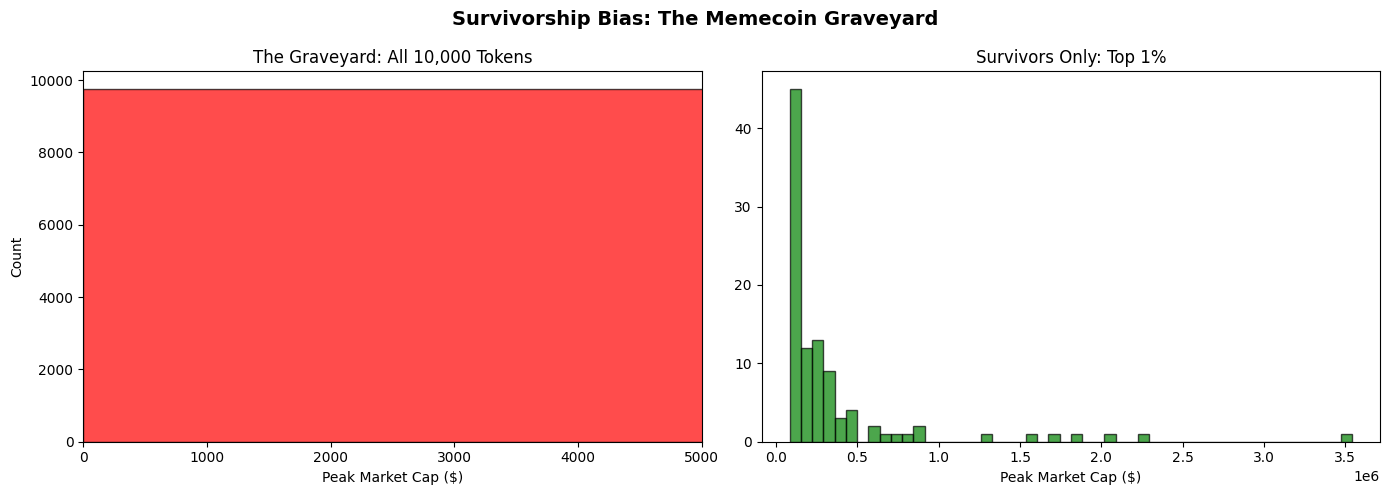

In [38]:
# Phase 4: AI Expansion
# Task 4.1: The "Memecoin Graveyard" Simulation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate 10,000 token launches
# Pareto Distribution (Power Law) — 99% of tokens are near zero
n_tokens = 10000

peak_market_cap = np.random.pareto(a=1, size=n_tokens) * 1000  # scale to dollars

# Create the two DataFrames
df_all = pd.DataFrame({'peak_market_cap': peak_market_cap})

# Survivors = Top 1% only
threshold    = np.percentile(peak_market_cap, 99)
df_survivors = df_all[df_all['peak_market_cap'] >= threshold]

# Evaluate: Print the bias
print(f"Total tokens:         {len(df_all)}")
print(f"Survivors (Top 1%):   {len(df_survivors)}")
print(f"Mean Market Cap (All):       ${df_all['peak_market_cap'].mean():,.2f}")
print(f"Mean Market Cap (Survivors): ${df_survivors['peak_market_cap'].mean():,.2f}")
print(f"Survivorship Bias Multiplier: {df_survivors['peak_market_cap'].mean() / df_all['peak_market_cap'].mean():.1f}x")

# Dual Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: The Graveyard (all tokens)
axes[0].hist(df_all['peak_market_cap'], bins=100, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('The Graveyard: All 10,000 Tokens')
axes[0].set_xlabel('Peak Market Cap ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 5000)

# Right: Survivors only
axes[1].hist(df_survivors['peak_market_cap'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Survivors Only: Top 1%')
axes[1].set_xlabel('Peak Market Cap ($)')

plt.suptitle('Survivorship Bias: The Memecoin Graveyard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()